# Interplanetary Mission Design

## 3D Geometry
When designing interplanetary missions the assumption that the departure and the arrival planets are coplanar with circular orbits is not valid anymore. Defining the Earth's orbital plane respect to the Sun as the **ecliptic plane**, each planet has a different inclination respect to it. The following table reports this parameter for each planet of the Solar system, as well as the orbit's eccentricity respec to the Sun:


| Planet       | Mercury | Venus | Earth | Mars  | Jupiter | Saturn | Uranus | Neptune | Pluto |
|--------------|---------|-------|-------|-------|---------|--------|--------|---------|-------|
| Inclination  | 7°      | 3.39° | 0°    | 1.85° | 1.3°    | 2.49°  | 0.77°  | 1.77°   | 17.2° |
| Eccentricity | 0.205   | 0.006 | 0.016 | 0.093 | 0.048   | 0.054  | 0.047  | 0.008   | 0.248 |

In 3-dimensional space, the fact that the planetary orbits are not strictly coplanar often requires $\Delta V$ out of the ecliptic plane, considering that the transfer orbit's plane shall contain the Sun, the departure planet at launch epoch and the arrival planet at arrival epoch:

<center><img src="Images/interplanetary3dTransfers.png" alt="Drawing" style="width: 500px;"/><center>

&nbsp;  

In the above Figure, $i_p$ is the inclination of the arrival planet's orbit respect to the ecliptic. When $i_p=0$, we fall into the planar case, where the general approach is to have the departing planet at launch epoch and the arrival planet at arrival epoch on opposite side of the Sun (defining $\psi$ as the **transfer angle**, $\psi$=180°).

When $i_p \neq 0$, the transfer arc shall be inclined respect to the ecliptic, and the inclination is function of the position of the arrival planet along its trajectory. When $\psi$ approaches 180°, the inclination respect to the ecliptic approaches 90°. This is the worse possible condition, since it completely nullify the effects of the Earth's orbital velocity. The sole exception to this rule is the **nodal tranfer mission**, where departure occurs at one node of the target's orbit and the arrival is on the other node. In this special case the transfer orbit plane is not determined and may belong to the ecliptic plane, requiring a lower departure energy.

<center><img src="Images/nodalTransfers.png" alt="Drawing" style="width: 500px;"/><center>

&nbsp;  

The $\psi = 180^o$ transfer ridge subdivides the mission space into two basic regions : the **Type I** trajectoris, for transfer arcs below 180°, and the **Type II** trajectories, for transfer arcs above 180°.

## Lambert Problem

The problem of determining a transfer orbit between two position vectors (in this case, the position of the departing planet at launch epoch and the position of the arrival planet at arrival epoch) given the transfer flight duration is called **Lambert problem**; it allows to determine the $\Delta V$ needed to get from one orbit to the other.

<center><img src="Images/lambert_1.png" alt="Drawing" style="width: 600px;"/><center>

&nbsp; 

In the above figure, $P_1$ is the position of the departing planet at launch date, while $P_2$ is the position of the arrival planet at arrival date. 

$\overrightarrow{v_{p1}}$ is the velocity of the departing planet; to get into the transfer orbit, the spacecraft needs a velocity change $\Delta V_1$ to reach  $\overrightarrow{v_{1}}$. When it arrives at $P_2$, its velocity is $\overrightarrow{v_{2}}$, so a second maneuver ($\Delta V_2$) is needed to get $\overrightarrow{v_{p2}}$. The overall velocity change is $\Delta V = \Delta V_1 + \Delta V_2$


## Porkchop Plots

The Lambert problem can be solved to derive the total $\Delta V$ needed for each of the possible pairs within a range of proposed departure and arrival dates. **Porkchop plots** are used to report in a graphical way the $\Delta V$ (or, alternatively, the energy $C3$) as function of the departure and arrival dates:

<center><img src="Images/porkchopSynodic.png" alt="Drawing" style="width: 700px;"/><center>


From the Figure above we can see for each coordinate set of arrival/departure dates, a specific $\Delta V$ value is defined. Each coloured area on the plot represents a transfer opportunity from one planet to the other. These areas are repeating depending on the **synodic period**, which is the time period needed for the two planets to repeat their relative geometry. Defined $n_1$ and $n_2$ the mean motion values of the two planets we have:

&nbsp; 

$$T_{syn}= \frac{2 \pi}{\begin{vmatrix}n_2-n_1\end{vmatrix}}$$


| Planet                 | Mercury | Venus | Mars | Jupiter | Saturn | Uranus | Neptune | Pluto |
|------------------------|---------|-------|------|---------|--------|--------|---------|-------|
| Synodic Period (years) | 0.31    | 1.59  | 2.13 | 1.09    | 1.03   | 1.01   | 1.00    | 1.00  |

&nbsp; 

The Figure below focuses on a specific transfer opportunity. The ballistic contour plots of departure energy reveal a unique mission space consisting of two distinguishable trajectory areas. The two trajectory areas are relevant to **Type I** (transfer arc less than 180°) and **Type II**  (transfer arc greater than 180°) trajectories.

<center><img src="Images/porkchop.png" alt="Drawing" style="width: 600px;"/><center>

&nbsp; 

Type I trajectories have shorter trip times and lower error sensitivity which often makes them desirable for interplanetary trajectories. Due to the longer distance traveled, Type II trajectories have longer trip times but usually require a lower ΔV than Type I trajectories.

It should be noted that there are two minimum energy areas within the ballistic plots, one of which is associated with a Type I transfer (bottom) and the other with a Type II transfer (top) . A notable ridge passes diagonally from the lower left to the upper right of the mission space separating the Type I and Type II trajectories. This dramatic rise is attributed to near-180° transfer angle trajectories. If the geometry allows, the two areas are joined by a small 'bridge', which defines a nodal transfer.

As example, the following table reports the Earth to Mars transfer opportunities spanning from 2026 to 2031. Departure and arrival time spans can be used in the above code to get the relevant Porkchop plots

| Earth Mars Transfers | 2026       | 2028       | 2031       | 2033       | 2035       |
|----------------------|------------|------------|------------|------------|------------|
| First departure      | 04-08-2026 | 05-09-2028 | 25-10-2030 | 27-12-2032 | 18-03-2035 |
| Last departure       | 11-01-2027 | 12-02-2029 | 03-04-2031 | 05-06-2033 | 25-08-2035 |
| First arrival        | 01-03-2027 | 01-05-2029 | 20-05-2031 | 20-06-2033 | 01-10-2035 |
| Last arrival         | 05-04-2028 | 29-03-2030 | 01-04-2032 | 31-05-2034 | 28-10-2036 |

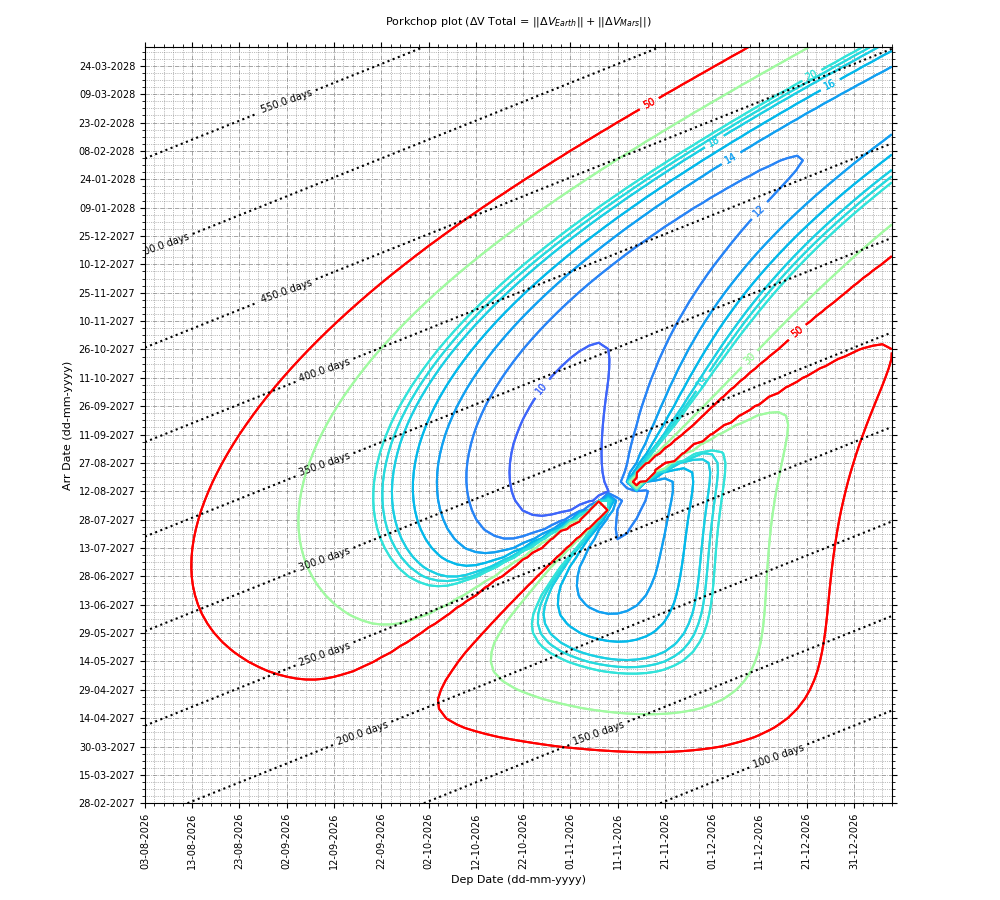

In [1]:
from routines import *
from porkchop import *
%matplotlib widget

########################################## INPUT DATA ##########################################################
# define departure and arrival planets
dep_planet = 'Earth'
arr_planet = 'Mars'

# departure range
first_dep_date = '04-08-2026'; #(format yyyy-mm-dd)
last_dep_date  = '11-01-2027'; #(format yyyy-mm-dd)

# arrival range
first_arr_date = '01-03-2027'; #(format yyyy-mm-dd)
last_arr_date  = '05-04-2028'; #(format yyyy-mm-dd)

# variable to plot ('delv_plot' or 'c3_plot')
plot_type = 'delv_plot'

################################################################################################################

PlotPorkchop(dep_planet, arr_planet, first_dep_date, last_dep_date, first_arr_date, last_arr_date, plot_type)

## Transfer Orbit Calculation

Flight Time = 229.0 days
V1∞    = 3.5534354407676214 km/sec
V2∞    = 4.327888147472745 km/sec
V∞ tot = 7.881323588240367 km/sec


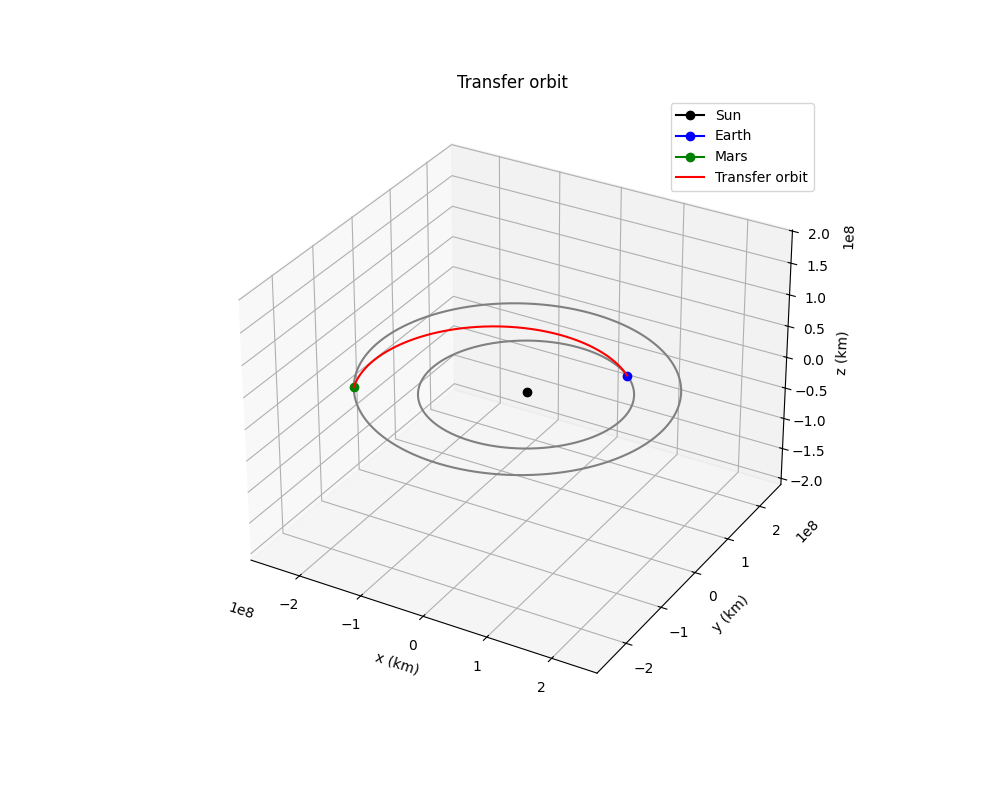

In [2]:
from astrodynamics import *
from routines import *
import lambert as lb
%matplotlib widget

########################################## INPUT DATA ##########################################################
dep_planet = 'Earth'
dep_date = '11-11-2026'  #(format dd-mm-yyyy)

arr_planet = 'Mars'
arr_date = '28-06-2027'  #(format dd-mm-yyyy)
################################################################################################################

# departure Julian Date
jd_dep = JdFromGregorianDdMmYyyy(dep_date)
# arrival Julian Date
jd_arr = JdFromGregorianDdMmYyyy(arr_date)

PlotTransfer('Sun', dep_planet, arr_planet, jd_dep, jd_arr, 1000)

## Launch/Injection Geometry

The solution of the Lambert problem for a specific pair of departure/arrival dates gives us the required $\Delta V$ to get the relevant transfer orbit or, in other words, the mission-required outgoing vector $v_{\infty}$. This launch vector is referenced to an Earth Centered  Inertial coordinate system. We here define the following:

- The declination $\delta_{\infty}$, the angle between the $v_{\infty}$ vector and the equatorial plane
- The right ascension $\alpha_{\infty}$, the angle between the projection of the $v_{\infty}$ vector with the equatorial plane and the vernal equinox direction  

<center><img src="Images/outgoingAlphaDelta.png" alt="Drawing" style="width: 700px;"/><center>  

&nbsp;  
The outgoing vector is univocally defined knowing $v_{\infty}^2$, $\delta_{\infty}$, and $\alpha_{\infty}$; the problem now is how to inject the spacecraft from some parking orbit into the desired hyperbolic orbit. 



### Departing Hyperbolas

To get into a tangential heliocentric Hohmann transfer orbit at the edge of the Earth SOI, the orbital plane of the departure hyperbola has to include the center of mass and the velocity vector of the departing planet (i.e., the asymptotic velocity vector $v_{\infty}$ has to be along $V_1$). If we rotate it about the outgoing asymptote, a locus of injection points to achieve one of these departure hyperbolas is then generated. The center of this locus is the vectorial inverse of the outgoing asymptote.

<center><img src="Images/departureHyperbola.png" alt="Drawing" style="width: 700px;"/><center>

Rotating the hyperbola in this way sweeps out a surface of revolution on which lie all possible departure hyperbolas. The periapse of the hyperbola traces out a circle which is the base of a cone with vertex at the center of the planet. 

<center><img src="Images/departingHyperbola.png" alt="Drawing" style="width: 650px;"/><center>

The angular radius $\beta$ of the locus is defined as **angular extent**. It is small for hyperbolic orbits with low eccentricity and grows for orbits with higher eccentricity (so, higher energy). We here remember that: 

 $$e=1+\frac{r_{park} v_{\infty}^{2}}{\mu_1}$$

 ...so the eccentricity is related to $v_{\infty}$ and, consequently, to $C3$: The higher the $v_{\infty}$, the higher $e$. Finally, we have:

 $$\beta = \arccos(\frac{1}{e})$$

The radius of this circle is: 

$$ r_{dep} = r_p \sin{\beta} = r_p \sin (\arccos(\frac{1}{e}))$$



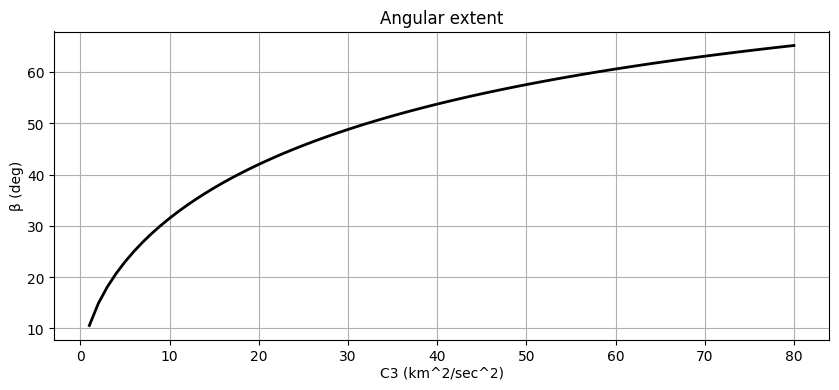

In [4]:
from routines import *
%matplotlib inline
########################################## INPUT DATA ##########################################################
departurePlanet = 'Earth'  # departing planet name
periAlt = 510.3           # altitude of periapsis (km)
vInf = 4             # hyperbolic eccess velocity (km/sec)
########################################## INPUT DATA ##########################################################

PlotAngularExtents(periAlt, departurePlanet)

### Getting the desired right ascension

Any right ascension can be met simply by changing the parking orbit's RAAN, which in turns means changing the launch epoch when a direct injection is planned.



### Getting the desired declination
There is some degree of flexibility in this because there are a number of hyperbolas whose outgoing asymptotes are identical, as shown below:

<center><img src="Images/departureHyperbola.png" alt="Drawing" style="width: 700px;"/><center>

If we take an hyperbola of a given periapsis radius and eccentricity and rotate it about the outgoing asymptote, a locus of injection points to achieve one of these departure hyperbolas is then generated. The center of this locus is the vectorial inverse of the outgoing asymptote. The angular radius of the locus (also named **angular extent** $\beta$) is small for hyperbolic orbits with low eccentricity (low energy) and grows for orbits with higher eccentricity. We here remember that: 

 $$e=1+\frac{r_{park} v_{\infty}^{2}}{\mu_1}$$

 ...so the eccentricity is related to $v_{\infty}$ and, consequently, to $C3$: The higher the $v_{\infty}$, the higher $e$. Finally, we have:

 $$\beta = \arccos(\frac{1}{e})$$


The declination of the outgoing asymptote has implications on the inclination of the departing orbit. The Figure above shows how the locus of the departing's hyperbolae perapse changes accordingly with the needed declination:

<center><img src="Images/declination.png" alt="Drawing" style="width: 900px;"/><center>
 
&nbsp;  

Note that not every declination can be reached. Referring to the above Figure, the angular extent is about 37°; we see that for $\delta_{\infty}$=-45° the locus does not intercept the equatorial plane. It follows that, for inclination less than the angular distance between the equatorial plane and the lowest point of the circle, we can't get the proper ignition conditions. In this specific case the minimum inclination of the departing orbit is 45°-37° = 8°.

The angular extent $\beta$ increases when the hyperbolic eccess velocity increases:

## Arrival Geometry

When sending a spacecraft to a celestial body in the Solar system, one reference frame often used upon arrival is the B-plane (Body Plane) frame. 

The B-plane is defined as a plane (attached to the arrival planet) which is normal to the incoming $v_{\infty}$ asymptote vector and that contains the target body’s center of mass. The trajectory plane and the B-plane are perpendicular, since the former contains the asymptote vector and the target body’s center of mass.

<center><img src="Images/b-plane1.png" alt="Drawing" style="width: 550px;"/><center> 

The intersection of the b-plane and the trajectory plane defines a line in space. The $\overrightarrow{\textbf{B}}$ vector is defined to lie along this line, starting on the focus and ending at the spot where the incoming asymptote pierces the b-plane; this is also called the **aim point**. It is defined using three unit vectors:

* $\overrightarrow{\textbf{S}}$, which lies in the trajectory frame and is parallel to the incoming hyperbolic asymptote, thus also parallel to the incoming $v_{\infty}$ asymptote vector

* $\overrightarrow{\textbf{T}}$ is defined as $\overrightarrow{\textbf{T}} = \frac{\overrightarrow{\textbf{S}}\times \overrightarrow{\textbf{N}}}{\begin{vmatrix}
\overrightarrow{\textbf{S}}\times \overrightarrow{\textbf{N}}
\end{vmatrix}}$, where $\overrightarrow{\textbf{N}}$ is either the arrival planets's polar vector or its orbit normal

* $\overrightarrow{\textbf{R}}$ completes the triad between $\overrightarrow{\textbf{T}}$ and $\overrightarrow{\textbf{R}}$